# **Exploratory Data Analysis**


## Objective
The objective of this analysis is to explore operational and environmental factors affecting delivery times and identify patterns useful for machine learning model development.

---

### Key Goals
- Understand dataset structure
- Analyze delivery time patterns
- Identify operational bottlenecks
- Detect missing values and anomalies
- Validate business hypotheses
- Discover relationships between variables

In [2]:
# Load Dataset
silver_df = spark.read.parquet(
    "Files/silver/cleaned_delivery_data"
)

display(silver_df)

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 8, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 5cf2d60f-b750-4b9b-ae42-2a2f61fc0592)

In [3]:
pdf = silver_df.toPandas()

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 9, Finished, Available, Finished, False)

In [4]:
# import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 10, Finished, Available, Finished, False)

In [5]:
pdf.head()

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 11, Finished, Available, Finished, False)

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,pqya338067587,36,4.7,18.927584,72.832585,19.017584,72.922585,2022-04-04,23:40:00,2026-05-10 23:50:00,Sandstorms,Low,van,Metropolitian,145,Clothing
1,njfz936670348,27,4.7,21.175975,72.795503,21.195975,72.815503,2022-03-15,10:55:00,2026-05-10 11:10:00,Sandstorms,Low,scooter,Urban,60,Sports
2,zzsx562940707,39,4.8,12.310972,76.659264,12.350972,76.699264,2022-04-01,12:30:00,2026-05-10 12:45:00,Cloudy,High,motorcycle,Metropolitian,140,Cosmetics
3,fkyd365052251,39,4.7,10.035573,76.336958,10.105573,76.406958,2022-02-14,18:30:00,2026-05-10 18:35:00,Windy,Medium,motorcycle,Urban,105,Cosmetics
4,lyyj446897623,30,4.2,11.025083,77.015393,11.105083,77.095393,2022-03-02,19:20:00,2026-05-10 19:30:00,Cloudy,Jam,scooter,Metropolitian,245,Home


In [6]:
pdf.info()

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 12, Finished, Available, Finished, False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43685 entries, 0 to 43684
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         43685 non-null  object        
 1   Agent_Age        43685 non-null  int32         
 2   Agent_Rating     43685 non-null  float64       
 3   Store_Latitude   43685 non-null  float64       
 4   Store_Longitude  43685 non-null  float64       
 5   Drop_Latitude    43685 non-null  float64       
 6   Drop_Longitude   43685 non-null  float64       
 7   Order_Date       43685 non-null  object        
 8   Order_Time       43685 non-null  object        
 9   Pickup_Time      43685 non-null  datetime64[us]
 10  Weather          43685 non-null  object        
 11  Traffic          43685 non-null  object        
 12  Vehicle          43685 non-null  object        
 13  Area             43685 non-null  object        
 14  Delivery_Time    43685 non-null  int32

In [7]:
pdf.describe()

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 13, Finished, Available, Finished, False)

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Pickup_Time,Delivery_Time
count,43685.000000,43685.000000,43685.000000,43685.000000,43685.000000,43685.000000,43685,43685.000000
mean,29.567861,4.633780,17.214543,70.668593,17.458164,70.829376,2026-05-10 17:37:47.728053,124.907588
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,2026-05-10 00:00:00,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,2026-05-10 14:35:00,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,2026-05-10 19:10:00,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.103162,2026-05-10 21:35:00,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,2026-05-10 23:55:00,270.000000
std,5.814436,0.334716,7.750885,21.459258,7.339296,21.136728,NaN,51.924227


# Data Readiness

The dataset used for exploratory analysis was previously cleaned and validated during the ingestion and silver-layer transformation process.

In [8]:
import warnings

warnings.filterwarnings("ignore")

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 14, Finished, Available, Finished, False)

# DELIVERY TIME ANALYSIS

Delivery times are expected to show moderate variability with occasional operational delays

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 15, Finished, Available, Finished, False)

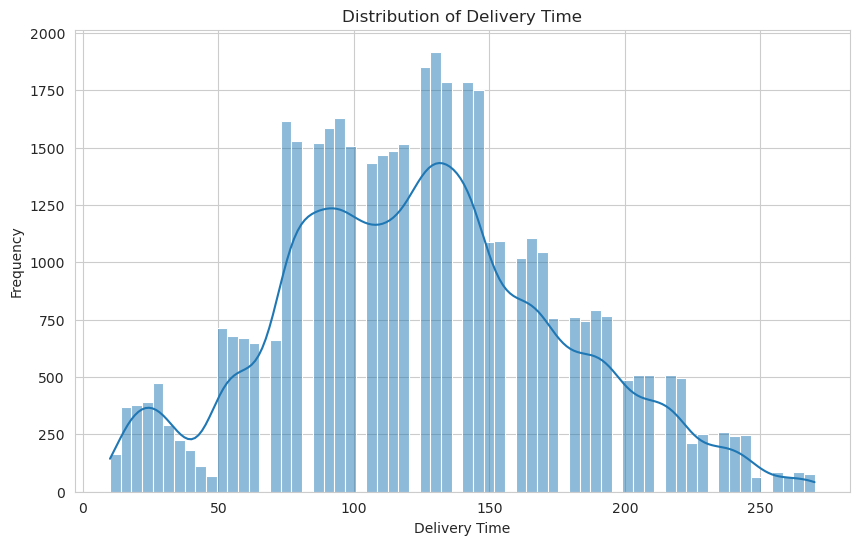

In [9]:
# How is delivery time distributed?

plt.figure(figsize=(10,6))

sns.histplot(
    pdf["Delivery_Time"],
    kde=True
)

plt.title("Distribution of Delivery Time")

plt.xlabel("Delivery Time")

plt.ylabel("Frequency")

plt.savefig(
    "/lakehouse/default/Files/screenshots/Distribution of Delivery Time.png",
    bbox_inches="tight"
)

plt.show()

Most delivery times are concentrated within a moderate range, while a few deliveries experience significantly longer delays. This indicates the presence of outliers possibly caused by traffic, weather, or distance.

# Delivery Time Outlier Analysis



StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 16, Finished, Available, Finished, False)

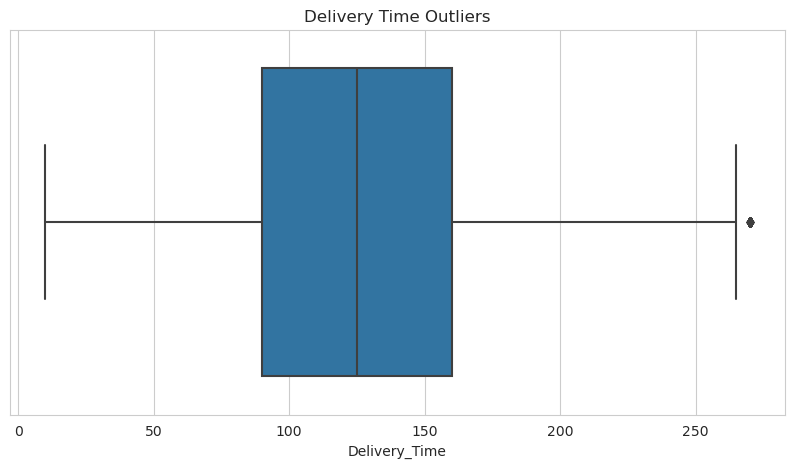

In [10]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=pdf["Delivery_Time"]
)

plt.title("Delivery Time Outliers")

plt.savefig(
    "/lakehouse/default/Files/screenshots/Delivery Time Outliers.png",
    bbox_inches="tight"
)

plt.show()


The target variable contains several operational outliers likely influenced by traffic congestion and long-distance deliveries.

# <u>_Operational Impact Analysis_</u>

This section evaluates how operational conditions affect delivery performance.

# Traffic Impact Analysis


Hypothesis

Higher traffic congestion significantly increases delivery delays.

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 17, Finished, Available, Finished, False)

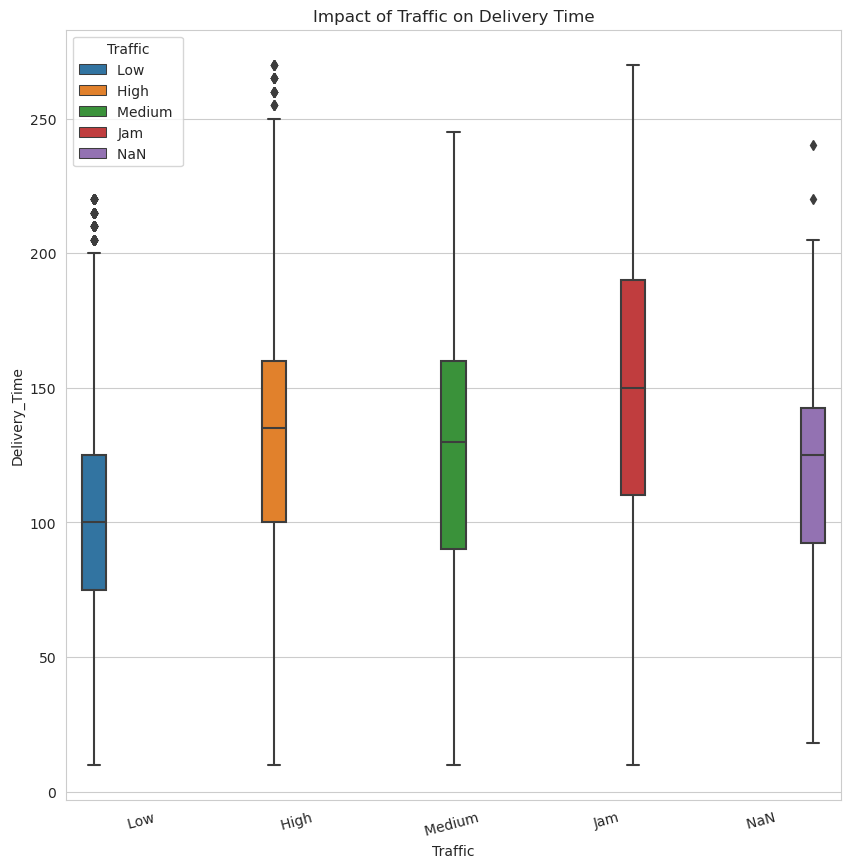

In [11]:
# Traffic Impcat Analysis

plt.figure(figsize=(10,10))

sns.boxplot(
    x="Traffic",
    y="Delivery_Time",
    data=pdf,
    hue="Traffic"
)

plt.title("Impact of Traffic on Delivery Time")

plt.xticks(rotation=15)

plt.savefig(
    "/lakehouse/default/Files/screenshots/Impact of traffic on Delivery Time.png",
    bbox_inches="tight"
)

plt.show()

High traffic conditions significantly increase delivery times compared to low and medium traffic conditions, confirming traffic as a major operational factor.

# Weather Impact Analysis

Hypothesis

Adverse weather conditions negatively affect delivery efficiency.

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 18, Finished, Available, Finished, False)

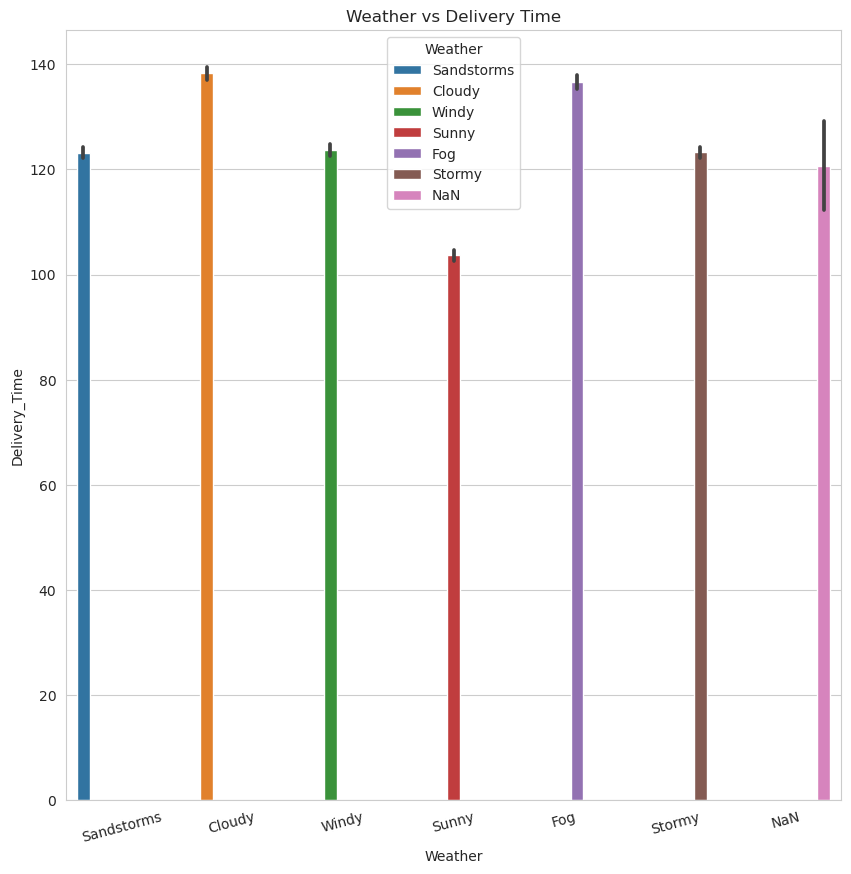

In [12]:
# Weather Impact 

plt.figure(figsize=(10,10))

sns.barplot(
    x="Weather",
    y="Delivery_Time",
    data=pdf,
    hue="Weather"
)

plt.title("Weather vs Delivery Time")

plt.xticks(rotation=15)

plt.savefig(
    "/lakehouse/default/Files/screenshots/Weather vs Delivey_Time.png",
    bbox_inches="tight"
)

plt.show()

Adverse weather conditions contribute to longer delivery durations, impacting overall logistics efficiency.

# Vehicle Efficiency Analysis

Hypothesis

Vehicle type influences delivery efficiency across operational environments.

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 19, Finished, Available, Finished, False)

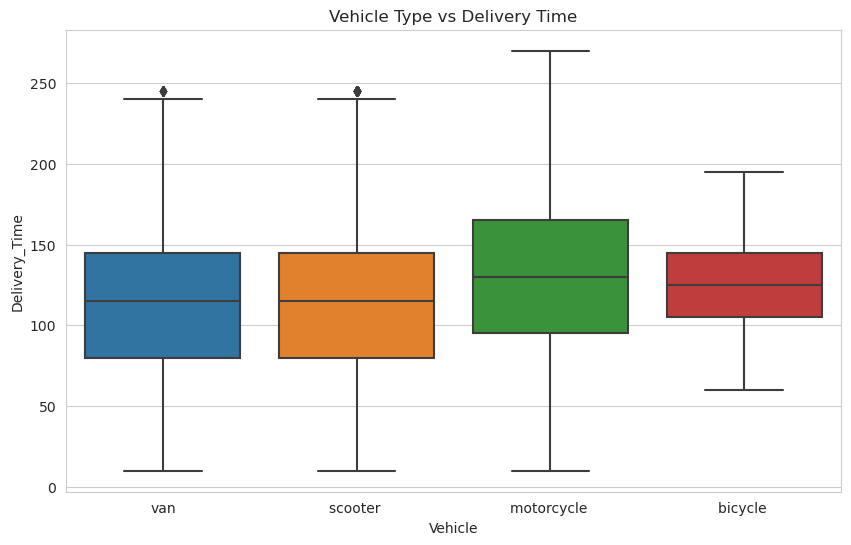

In [13]:
# Vehicle Effeciency

plt.figure(figsize=(10,6))

sns.boxplot(
    x="Vehicle",
    y="Delivery_Time",
    data=pdf
)

plt.title("Vehicle Type vs Delivery Time")

plt.savefig(
    "/lakehouse/default/Files/screenshots/Vehicle_type vs Delivery_Time.png",
    bbox_inches="tight"
)

plt.show()

Vehicle selection impacts delivery efficiency, particularly under dense urban traffic conditions.

# Product Category Analysis


Hypothesis

Different product categories may experience varying delivery durations due to handling requirements.

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 20, Finished, Available, Finished, False)

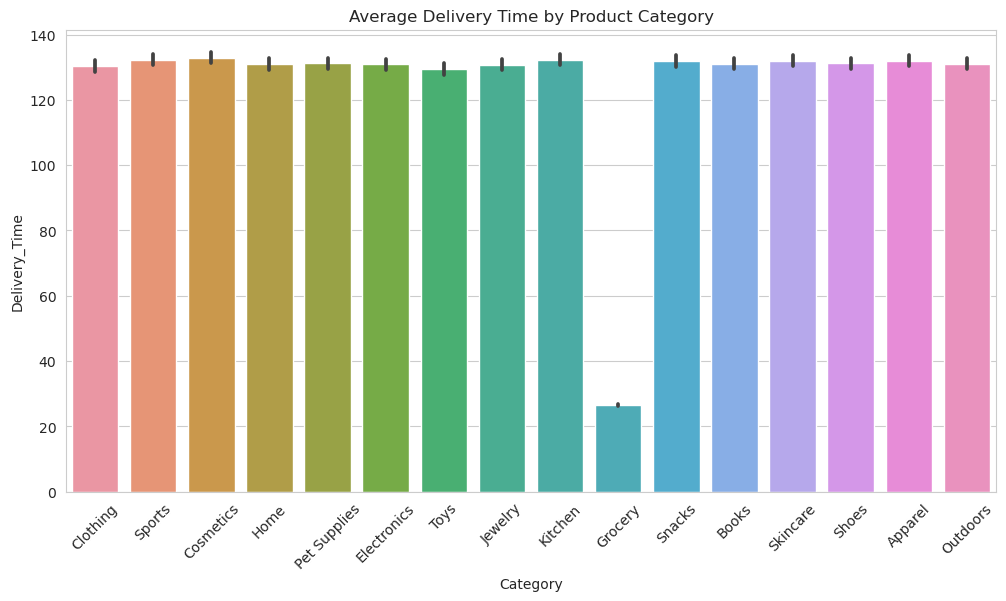

In [14]:
# Category Analysis

plt.figure(figsize=(12,6))

sns.barplot(
    x="Category",
    y="Delivery_Time",
    data=pdf
)

plt.title("Average Delivery Time by Product Category")

plt.savefig(
    "/lakehouse/default/Files/screenshots/Average _delivery_Time by Product_category.png",
    bbox_inches="tight"
)

plt.xticks(rotation=45)

plt.show()

Certain product categories experience longer average delivery times, potentially due to handling complexity, packaging requirements, or delivery priority.

# Area Analysis

Hypothesis

Metropolitan delivery areas experience higher operational delivery variability.

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 21, Finished, Available, Finished, False)

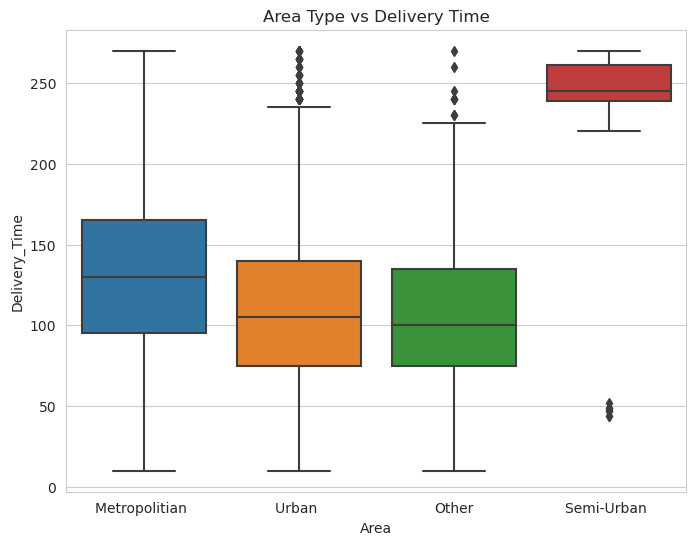

In [15]:
# Area Analysis

plt.figure(figsize=(8,6))

sns.boxplot(
    x="Area",
    y="Delivery_Time",
    data=pdf
)

plt.title("Area Type vs Delivery Time")

plt.savefig(
    "/lakehouse/default/Files/screenshots/Area_Type vs Delivery_time.png",
    bbox_inches="tight"
)

plt.show()

Metropolitan deliveries exhibit higher delivery variability due to operational complexity and traffic density.

# <u>_Agent Performance Analysis_</u>

Hypothesis

Agent-related characteristics may influence operational delivery efficiency.

# Agent Age Analysis

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 30, Finished, Available, Finished, False)

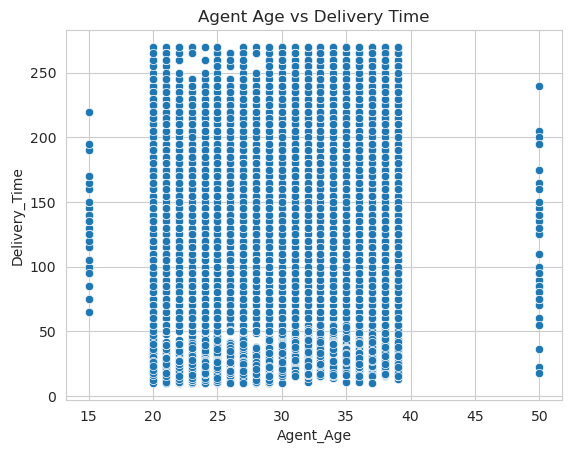

In [20]:
# plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Agent_Age",
    y="Delivery_Time",
    data=pdf
)

plt.title("Agent Age vs Delivery Time")

plt.savefig(
    "/lakehouse/default/Files/screenshots/Agent_age vs Delivery_Time.png",
    bbox_inches="tight"
)

plt.show()

Agent-related characteristics may influence operational delivery efficiency.

# Agent Rating Distribution

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 32, Finished, Available, Finished, False)

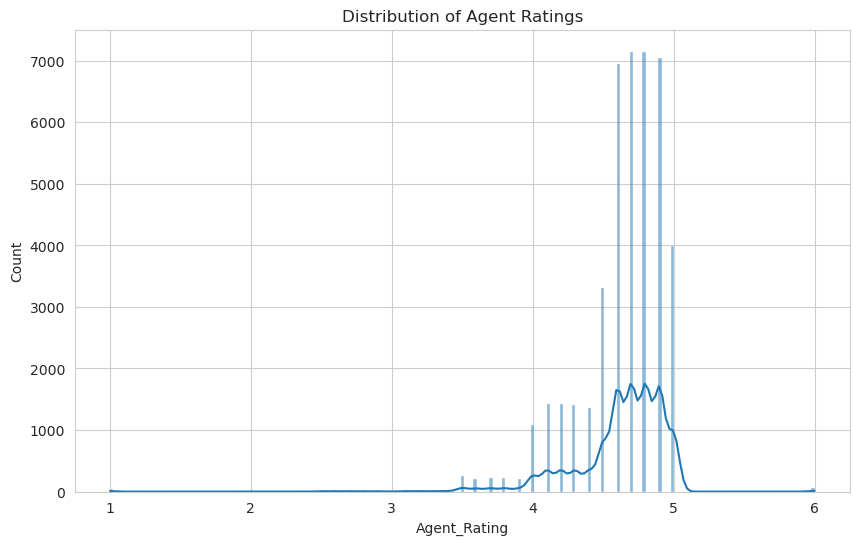

In [21]:
# Agent rating distribution

plt.figure(figsize=(10,6))

sns.histplot(
    pdf["Agent_Rating"],
    kde=True
)

plt.title("Distribution of Agent Ratings")

plt.savefig(
    "/lakehouse/default/Files/screenshots/Distribution of Agent Ratings.png",
    bbox_inches="tight"
)

plt.show()

Operational factors such as traffic and distance exhibit stronger influence than agent-related variables.

# <u>_Operational Distribution Analysis_</u>

This section analyzes the frequency distribution of operational delivery conditions.

# Vehicle Distribution

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 34, Finished, Available, Finished, False)

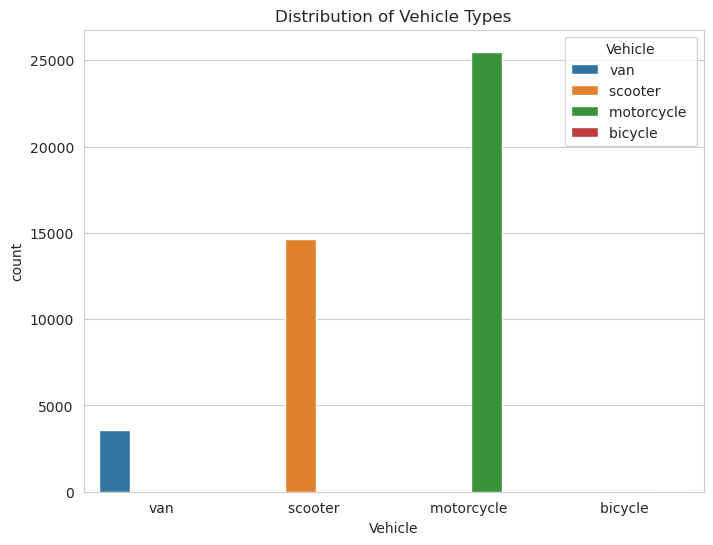

In [22]:
# Vehicle Count Analysis

plt.figure(figsize=(8,6))

sns.countplot(
    x="Vehicle",
    data=pdf,
    hue="Vehicle"
)

plt.title("Distribution of Vehicle Types")

plt.savefig(
    "/lakehouse/default/Files/screenshots/Distribution of Vehicle Types.png",
    bbox_inches="tight"
)

plt.show()

# Weather Distribution

Adverse weather conditions negatively affect delivery efficiency.

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 36, Finished, Available, Finished, False)

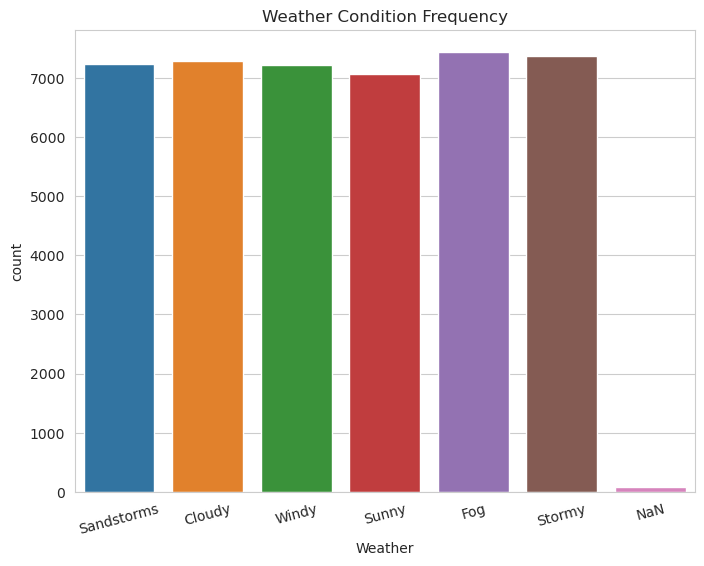

In [23]:
# Weather Distribution

plt.figure(figsize=(8,6))

sns.countplot(
    x="Weather",
    data=pdf
)

plt.title("Weather Condition Frequency")

plt.xticks(rotation=15)

plt.savefig(
    "/lakehouse/default/Files/screenshots/Weather Condition Frequency.png",
    bbox_inches="tight"
)

plt.show()


Extreme weather conditions moderately increase delivery duration variability.

# Traffic Distribution

Higher traffic congestion significantly increases delivery delays.

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 38, Finished, Available, Finished, False)

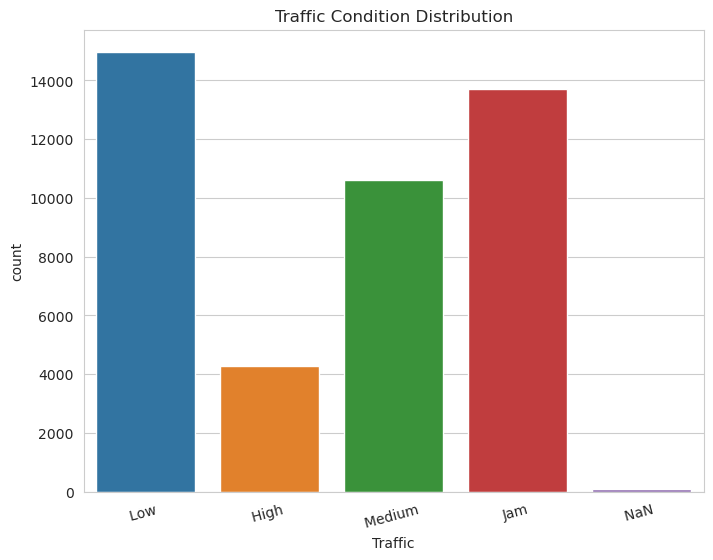

In [24]:
# Traffic Distribution

plt.figure(figsize=(8,6))

sns.countplot(
    x="Traffic",
    data=pdf
    
)

plt.title("Traffic Condition Distribution")

plt.xticks(rotation=15)

plt.savefig(
    "/lakehouse/default/Files/screenshots/Traffic_Condition_Distribution.png",
    bbox_inches="tight"
)

plt.show()





Traffic congestion strongly impacts delivery duration and operational efficiency.

# <u>_Correlation Analysis_</u>

This section analyzes relationships between numerical operational variables and delivery performance.

Hypothesis

Operational and distance-related variables are expected to exhibit meaningful relationships with delivery time.

StatementMeta(, 3adffdac-a6bc-4b92-aaeb-1b82281cd22c, 40, Finished, Available, Finished, False)

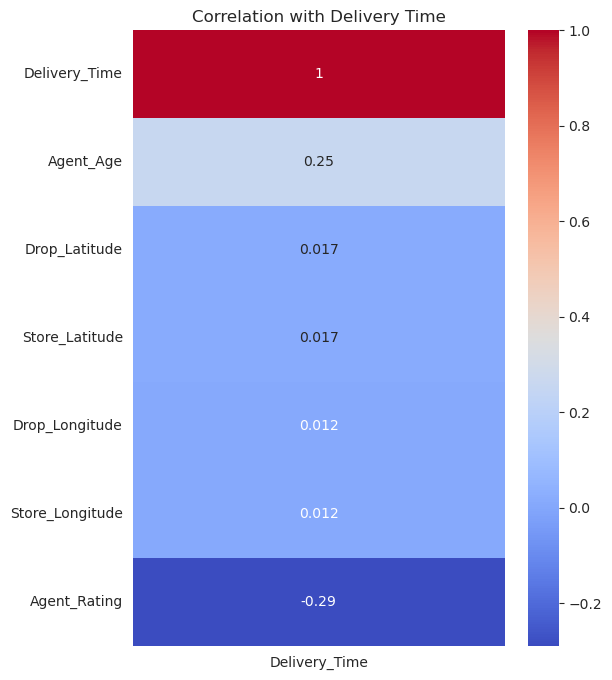

In [25]:
#Correlation Heatmap

numeric_cols = pdf.select_dtypes(
    include=np.number
)

corr_matrix = numeric_cols.corr()

target_corr = corr_matrix[["Delivery_Time"]].sort_values(
    by="Delivery_Time",
    ascending=False
)

plt.figure(figsize=(6,8))

sns.heatmap(
    target_corr,
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation with Delivery Time")

plt.savefig(
    "/lakehouse/default/Files/screenshots/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

Distance and operational variables demonstrate meaningful relationships with delivery performance.

# <u>**Key Business Insights**</u>

- Traffic congestion significantly impacts delivery delays.
- Delivery distance strongly influences operational performance.
- Metropolitan regions exhibit higher delivery variability.
- Vehicle selection affects operational efficiency.
- Weather conditions moderately impact logistics performance.
- Rush-hour conditions contribute to operational delays.

# <u>**Next Steps**</u>

The insights derived from EDA will guide:

- feature engineering
- preprocessing
- machine learning model development
- operational optimization strategies